<img src="https://www.unir.net/wp-content/uploads/2019/11/Unir_2021_logo.svg" width="240" height="240" align="right"/>

<center><h1>Técnicas de Inteligencia Artificial</header1></center>
<left><h1>Actividad 1. Laboratorio: Árboles de decisión, reglas y ensemble learning</header1></left>

Presentado por: Nombres Apellidos  <br>
Fecha: DD/MM/2022

## Importación de librerias necesarias

In [234]:
#Para esta actividad se importarán las siguientes librerías:
import pandas as pd

# Librerías para los modelos
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Librerías para gráficas
import matplotlib.pyplot as plt
import seaborn as sns


## Cargar el Dataset

In [235]:
#Código para cargar el Dataset
url = 'https://raw.githubusercontent.com/oscar-unir/TIA/main/datasets/car/Laboratorio_dataset_car.csv'

try:
    df = pd.read_csv(url, sep=';')
except Exception as e:
    print(f"Error al cargar el dataset: {e}")
    # Si no se puede cargar el dataset desde la URL, se carga desde el archivo local debe estar en el mismo directorio raiz
    df = pd.read_csv('Laboratorio_dataset_car.csv',sep=';')

df.head()


,Buying,Maintenance,Doors,Person,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


## Explique el problema a resolver. 
Descripción del problema. Tipo de problema (justifique). Variable objetivo, variables de entrada. Utilidad de su posible solución. Elementos adicionales que considere relevantes: 


Predecir si un coche es aceptable o no según sus características. Es un problema de clasificación supervisada porque cada instancia tiene una etiqueta de clase conocida.


## Caracterización del Dataset

Se incluye una descripción de los datos con:

>- Número de clases de la variable objetivo, indicando que representan dichas clases y el tipo de valor que toman.
>- Número de instancias en total.
>- Número de instancias pertenecientes a cada clase.
>- Número de atributos de entrada, su significado y tipo.
>- ¿Hay algún valor de atributo desconocido?

Se incorporá una descripción (EDA) del conjunto de datos utilizado. Se analiza el dataset proporcionando, se muestra al menos algunas de sus características mediante tablas y al menos algunas de ellas en modo gráfico (p.ej., histogramas, diagramas de dispersión, diagramas de cajas y bigotes, etc.)


In [236]:
# ¿Cuántas clases tiene la variable objetivo y qué representan?
clases = df['class'].unique()
print(f"Número de clases: {len(clases)}")
print(f"Clases: {clases}") 
## ['unacc', 'acc', 'vgood', 'good']

# ¿Cuántas instancias en total?
# Las instancias son las filas del dataset
print(f"\nTotal de instancias: {len(df)}")

# ¿Cuántas instancias por clase?
print("\nInstancias por clase:")
conteo = df['class'].value_counts()
instancias = df.groupby('class').size()
porcentaje = df.groupby('class').size()/len(df)*100

print(f"{instancias} - {porcentaje}")    


# ¿Cuántos atributos de entrada hay y qué valores toman?
atributos = [col for col in df.columns if col != 'class']
print(f"Número de atributos de entrada: {len(atributos)}")
print(f"Tipo de todos los atributos: Nominal Discreto (texto)\n")

print("Detalle de cada atributo:")
for col in atributos:
    valores = df[col].unique().tolist()
    print(f"  {col}: {valores}")
    
# ¿Hay valores nulos o desconocidos?
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos)

if nulos.sum() == 0:
    print("\nConclusión: no hay valores desconocidos en el dataset.")
else:
    print(f"\nConclusión: hay {nulos.sum()} valores desconocidos en total.")

Número de clases: 4
Clases: <StringArray>
['unacc', 'acc', 'vgood', 'good']
Length: 4, dtype: str

Total de instancias: 1750

Instancias por clase:
class
acc       390
good       75
unacc    1215
vgood      70
dtype: int64 - class
acc      22.285714
good      4.285714
unacc    69.428571
vgood     4.000000
dtype: float64
Número de atributos de entrada: 6
Tipo de todos los atributos: Nominal Discreto (texto)

Detalle de cada atributo:
  Buying: ['vhigh', 'high', 'med', 'low']
  Maintenance: ['vhigh', 'high', 'med', 'low']
  Doors: ['2', '3', '4', '5more']
  Person: ['2', '4', 'more']
  lug_boot: ['small', 'med', 'big']
  safety: ['low', 'med', 'high']
Valores nulos por columna:
Buying         0
Maintenance    0
Doors          0
Person         0
lug_boot       0
safety         0
class          0
dtype: int64

Conclusión: no hay valores desconocidos en el dataset.


## Distribución de clases
¿Está el dataset balanceado?

El dataset está muy desbalanceado:

unacc tiene 1215 instancias — el 69.4% del total
acc tiene 390 — el 22.3%
good tiene 75 — solo el 4.3%
vgood tiene 70 — solo el 4%

Esto es crítico mencionarlo en el informe porque significa que el modelo va a ver muchísimos más ejemplos de coches inaceptables que de cualquier otra clase. Un modelo mal entrenado podría aprender a decir "unacc" para todo y aún así tener un 69% de accuracy, sin haber aprendido nada útil realmente.

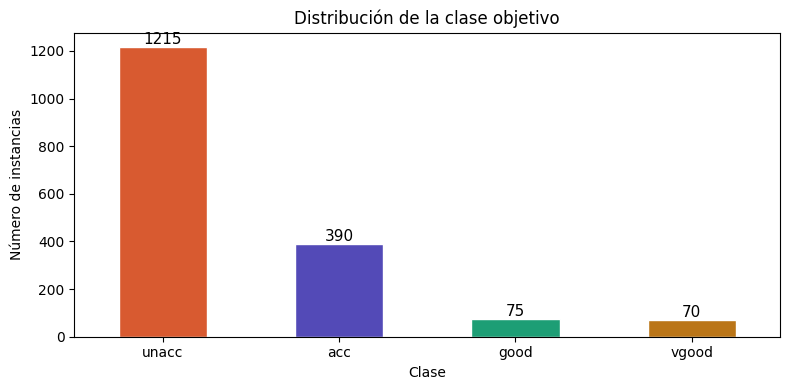

In [237]:
#Código que responde a la descripción anterior (incorpore las lineas de code necesarias. Describa cadas sentencia de código)
# Distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(8, 4))

colores = ['#D85A30', '#534AB7', '#1D9E75', '#BA7517']
df['class'].value_counts().plot(
    kind='bar', 
    ax=ax, 
    color=colores,
    edgecolor='white'
)

ax.set_title('Distribución de la clase objetivo')
ax.set_xlabel('Clase')
ax.set_ylabel('Número de instancias')
ax.tick_params(axis='x', rotation=0)

# Añade el número exacto encima de cada barra
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

## Distribución de atributos
¿Cómo se reparten los valores de cada atributo?
Los atributos de entrada están muy bien balanceados entre sus valores. Mira:

Buying: vhigh(443), med(438), low(437), high(432) — casi idénticos
Maintenance: igual, todos entre 432 y 447
Doors, Person, lug_boot, safety: mismo patrón

Esto significa que no hay sesgo en los atributos de entrada. El dataset fue construido de forma sistemática, probando todas las combinaciones posibles de valores. Eso es algo positivo para mencionar en el informe.

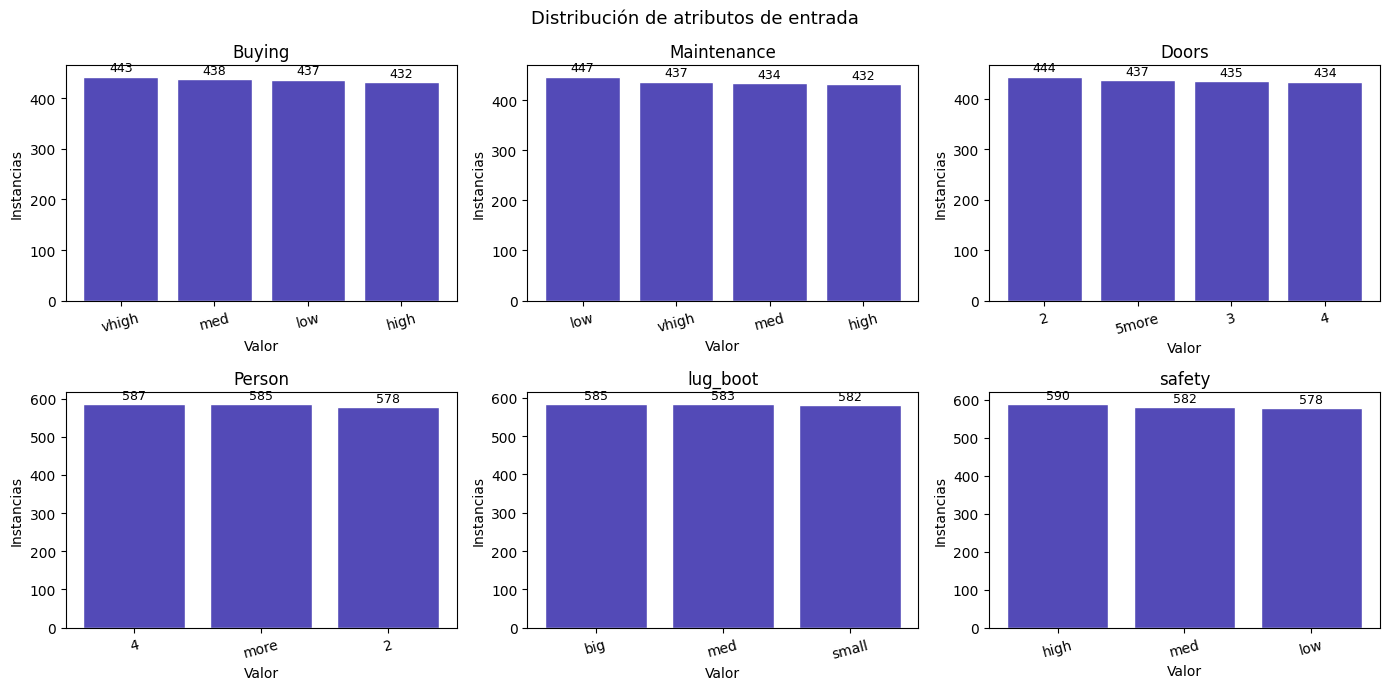

In [238]:
# ¿Cómo se distribuyen los valores de cada atributo de entrada?
atributos = ['Buying', 'Maintenance', 'Doors', 'Person', 'lug_boot', 'safety']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()  # convierte la matriz 2x3 en lista de 6 para iterar fácil

for i, col in enumerate(atributos):
    conteo = df[col].value_counts()
    axes[i].bar(
        conteo.index,
        conteo.values,
        color='#534AB7',
        edgecolor='white'
    )
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Instancias')
    axes[i].tick_params(axis='x', rotation=15)

    # Número encima de cada barra
    for barra in axes[i].patches:
        axes[i].text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 5,
            str(int(barra.get_height())),
            ha='center', va='bottom', fontsize=9
        )

plt.suptitle('Distribución de atributos de entrada', fontsize=13)
plt.tight_layout()
plt.show()

## Relación atributo vs clase 
¿Qué atributos influyen más en la clase?

En un par de párrafos haga un resumen de los principales hallazagos encontrados:    

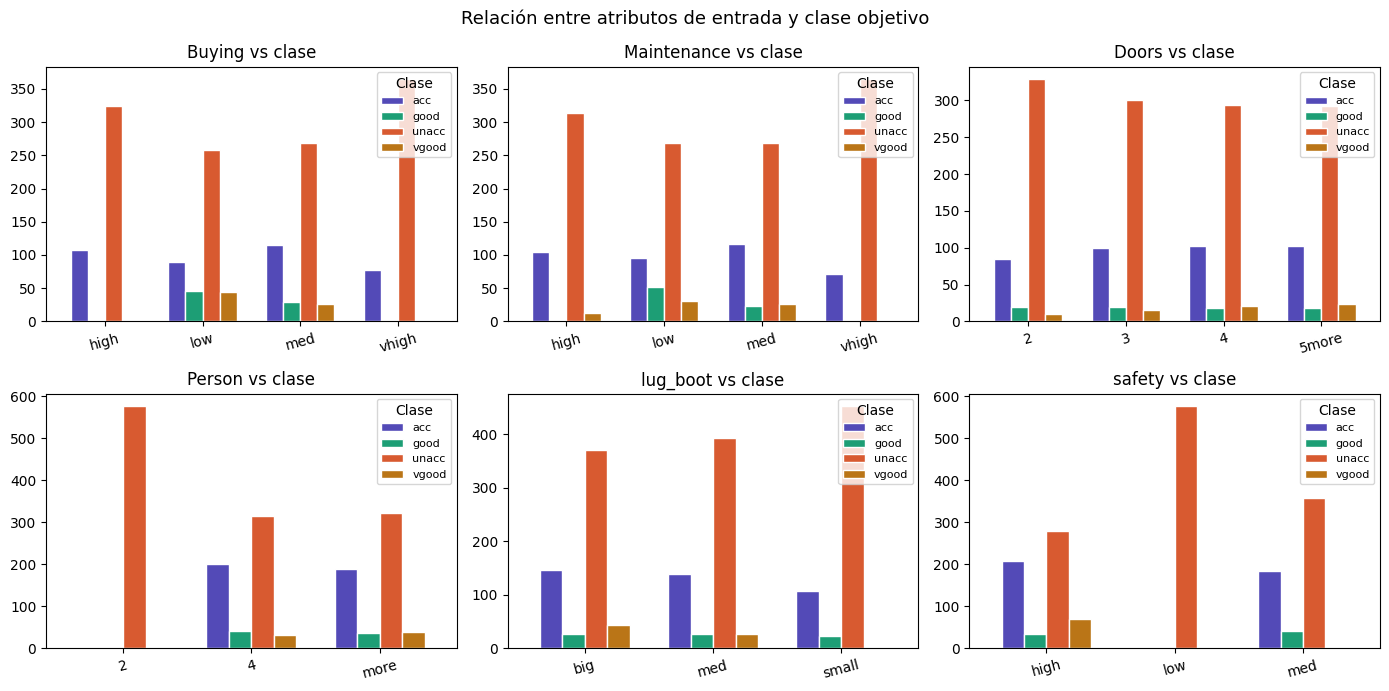

In [239]:
# ¿Cómo se relaciona cada atributo con la clase objetivo?
atributos = ['Buying', 'Maintenance', 'Doors', 'Person', 'lug_boot', 'safety']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

colores_clase = {
    'unacc': '#D85A30',
    'acc':   '#534AB7',
    'good':  '#1D9E75',
    'vgood': '#BA7517'
}

for i, col in enumerate(atributos):
    # Tabla de frecuencia: cuántas instancias de cada clase por cada valor del atributo
    tabla = pd.crosstab(df[col], df['class'])

    tabla.plot(
        kind='bar',
        ax=axes[i],
        color=[colores_clase[c] for c in tabla.columns],
        edgecolor='white',
        width=0.7
    )
    axes[i].set_title(f'{col} vs clase')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].legend(title='Clase', fontsize=8)

plt.suptitle('Relación entre atributos de entrada y clase objetivo', fontsize=13)
plt.tight_layout()
plt.show()

## Preprocesamiento del dataset. Transformaciones previas necesarias para la modelación
los atributos son texto (vhigh, low, small...) y scikit-learn solo entiende números. Hay que convertirlos.

Ejemplo:
Buying:  vhigh→0,  high→1,  med→2,  low→3
Safety:  low→0,    med→1,   high→2
class:   unacc→0,  acc→1,   good→2, vgood→3

In [240]:
#Código que realice las transformaciones necesarias para poder realizar los procesos de modelación.

# Creamos una copia del dataframe para no modificar el original
df_encoded = df.copy()

# Aplicamos LabelEncoder a cada columna
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Verificamos el resultado
print("Antes:")
print(df.head(3))
print("\nDespués:")
print(df_encoded.head(3))

Antes:
  Buying Maintenance Doors Person lug_boot safety  class
0  vhigh       vhigh     2      2    small    low  unacc
1  vhigh       vhigh     2      2    small    med  unacc
2  vhigh       vhigh     2      2    small   high  unacc

Después:
   Buying  Maintenance  Doors  Person  lug_boot  safety  class
0       3            3      0       0         2       1      2
1       3            3      0       0         2       2      2
2       3            3      0       0         2       0      2


## División del dataset en datos de entrenamiento y datos de test 

In [241]:
#Código que realice la división en entrenamiento y test, de acuerdo con la estretgia de evluación planeada. Describa cuál es.

# X son los atributos de entrada (todo menos la clase)
X = df_encoded.drop(columns=['class'])

# y es la variable objetivo (solo la clase)
y = df_encoded['class']

X_train, X_test, y_train, y_test = train_test_split(
    X,              # atributos de entrada
    y,              # variable objetivo
    test_size=0.2,  # 20% para test, 80% para entrenamiento
    random_state=42 # semilla para reproducibilidad
)

print(f"Total de instancias:        {len(df)}")
print(f"Instancias de entrenamiento: {len(X_train)} ({len(X_train)/len(df)*100:.0f}%)")
print(f"Instancias de test:          {len(X_test)} ({len(X_test)/len(df)*100:.0f}%)")

Total de instancias:        1750
Instancias de entrenamiento: 1400 (80%)
Instancias de test:          350 (20%)


## Ajuste de los modelos de clasificación propuestos

Justifique la selección de las dos propuestas de modelación seleccionadas:

Mejores hiperparámetros encontrados:
{'criterion': 'entropy', 'max_depth': 8}
Mejor puntuación de validación cruzada:
0.947142857142857
Árbol entrenado correctamente
Profundidad del árbol: 8
Número de hojas: 41


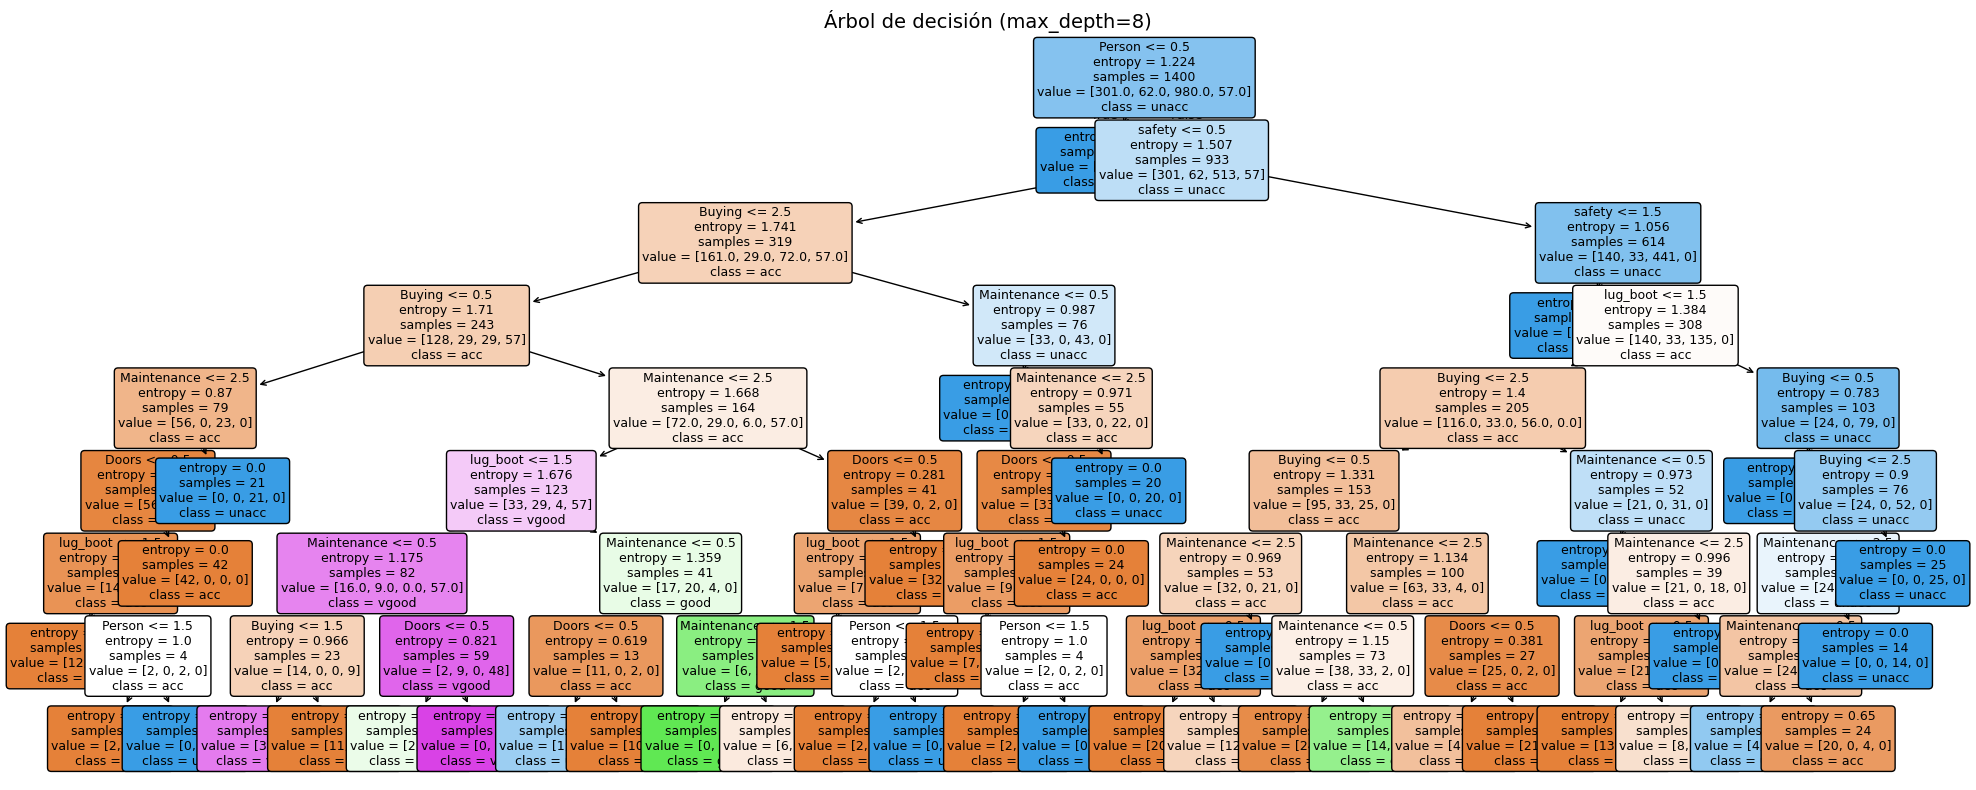

In [ ]:

#Código de ajuste del modelo de clasificación 1

# Creamos y entrenamos el modelo
arbol = DecisionTreeClassifier(random_state=42)

param_grid = {'criterion': ['gini', 'entropy', 'log_loss'], 'max_depth': [5,4,3,2]}

# Realizar la búsqueda de hiperparámetros utilizando GridSearchCV
grid_search = GridSearchCV(arbol, param_grid=param_grid, cv=10, return_train_score=True)
grid_search.fit(X_train, y_train)

# Imprimir los resultados
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print("Mejor puntuación de validación cruzada:")
print(grid_search.best_score_)

# Modelo decision tree con parametros optimizados
best_tree = grid_search.best_estimator_
best_crterio=grid_search.best_params_.get('criterion')

print("Árbol entrenado correctamente")
print(f"Profundidad del árbol: {best_tree.get_depth()}")
print(f"Número de hojas: {best_tree.get_n_leaves()}")

# Visualizamos el árbol resultante
fig, ax = plt.subplots(figsize=(20, 8))

plot_tree(
    best_tree,
    feature_names=X.columns.tolist(),   # nombres de los atributos
    class_names=['acc','good','unacc','vgood'],  # nombres de las clases
    filled=True,       # colorea los nodos según la clase mayoritaria
    rounded=True,      # bordes redondeados
    fontsize=9,
    ax=ax
)

plt.title(f'Árbol de decisión (max_depth={best_tree.get_depth()})', fontsize=14)
plt.tight_layout()
plt.show()

Random Forest entrenado correctamente
Número de árboles: 100
Número de atributos evaluados por árbol: sqrt


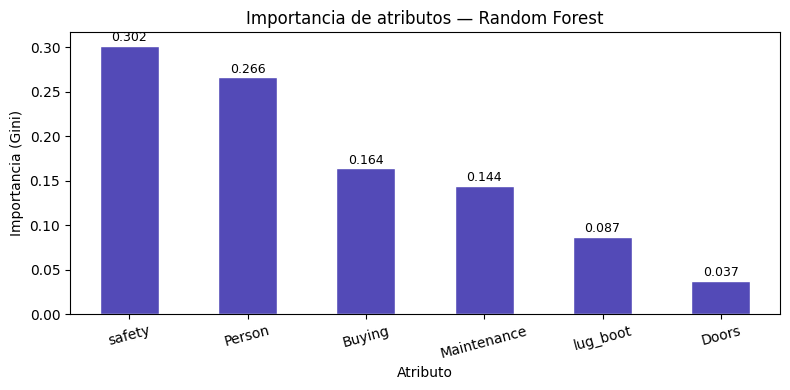

In [ ]:
#Código de ajuste del modelo de clasificación 2
bosque = RandomForestClassifier(
    n_estimators=100,    # 100 árboles en el ensemble
    criterion=best_crterio,    # mismo criterio que el árbol individual (optimizado)
    max_depth=best_tree.get_depth(), # misma profundidad máxima por hiperparametros
    random_state=42,
)

bosque.fit(X_train, y_train)

print("Random Forest entrenado correctamente")
print(f"Número de árboles: {bosque.n_estimators}")
print(f"Número de atributos evaluados por árbol: {bosque.max_features}")

# ¿Qué atributos considera más importantes el Random Forest?
importancias = pd.Series(
    bosque.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
importancias.plot(
    kind='bar',
    ax=ax,
    color='#534AB7',
    edgecolor='white'
)
ax.set_title('Importancia de atributos — Random Forest')
ax.set_xlabel('Atributo')
ax.set_ylabel('Importancia (Gini)')
ax.tick_params(axis='x', rotation=15)

for barra in ax.patches:
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.002,
        f'{barra.get_height():.3f}',
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.show()

## Evaluación de cada modelo

Al menos incluya:

+ Instancias clasificadas correctamente
+ Instancias clasificadas incorrectamente
+ TP Rate
+ FP Rate
+ Matriz de confusión


In [244]:
#Código para mostrar la evaluación del modelo de clasificación 1
# Predicciones de arboles de decisión
y_pred_arbol  = best_tree.predict(X_test)

# Reporte completo de cada modelo
print("=" * 50)
print("ÁRBOL DE DECISIÓN")
print("=" * 50)
print(classification_report(y_test, y_pred_arbol,
      target_names=['acc','good','unacc','vgood']))



ÁRBOL DE DECISIÓN
              precision    recall  f1-score   support

         acc       0.88      0.82      0.85        89
        good       0.43      0.77      0.56        13
       unacc       0.98      0.97      0.97       235
       vgood       0.85      0.85      0.85        13

    accuracy                           0.92       350
   macro avg       0.79      0.85      0.81       350
weighted avg       0.93      0.92      0.92       350



Construya un párrafo con los principales hallazgos.

In [245]:
#Código  para mostrarla evaluación del modelo de clasificación 2
y_pred_bosque = bosque.predict(X_test)

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, y_pred_bosque,
      target_names=['acc','good','unacc','vgood']))


RANDOM FOREST
              precision    recall  f1-score   support

         acc       0.88      0.94      0.91        89
        good       1.00      0.54      0.70        13
       unacc       0.98      0.98      0.98       235
       vgood       0.83      0.77      0.80        13

    accuracy                           0.95       350
   macro avg       0.92      0.81      0.85       350
weighted avg       0.95      0.95      0.95       350



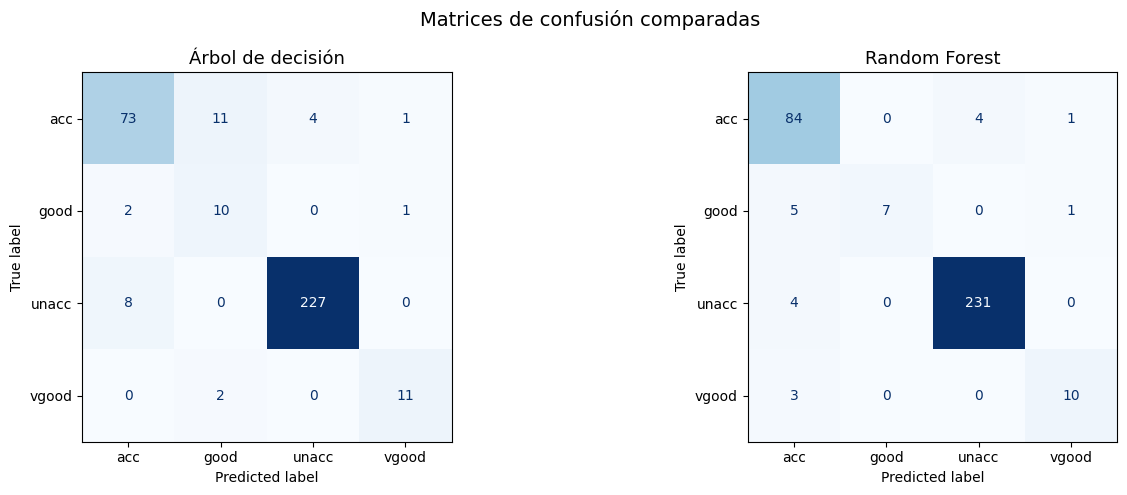

Árbol de decisión:
  Correctos:   321 de 350 (91.7%)
  Incorrectos: 29 de 350 (8.3%)

Random Forest:
  Correctos:   332 de 350 (94.9%)
  Incorrectos: 18 de 350 (5.1%)


In [246]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clases = ['acc', 'good', 'unacc', 'vgood']

for ax, modelo, nombre, y_pred in zip(
    axes,
    [best_tree, bosque],
    ['Árbol de decisión', 'Random Forest'],
    [y_pred_arbol, y_pred_bosque]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre, fontsize=13)

plt.suptitle('Matrices de confusión comparadas', fontsize=14)
plt.tight_layout()
plt.show()

# Añade esta celda para ver el accuracy de cada modelo
aciertos_arbol  = (y_pred_arbol  == y_test).sum()
aciertos_bosque = (y_pred_bosque == y_test).sum()
total = len(y_test)

print(f"Árbol de decisión:")
print(f"  Correctos:   {aciertos_arbol} de {total} ({aciertos_arbol/total*100:.1f}%)")
print(f"  Incorrectos: {total-aciertos_arbol} de {total} ({(total-aciertos_arbol)/total*100:.1f}%)")

print(f"\nRandom Forest:")
print(f"  Correctos:   {aciertos_bosque} de {total} ({aciertos_bosque/total*100:.1f}%)")
print(f"  Incorrectos: {total-aciertos_bosque} de {total} ({(total-aciertos_bosque)/total*100:.1f}%)")

Construya un párrafo con los principales hallazgos.

## Comparación del desempeño de modelos

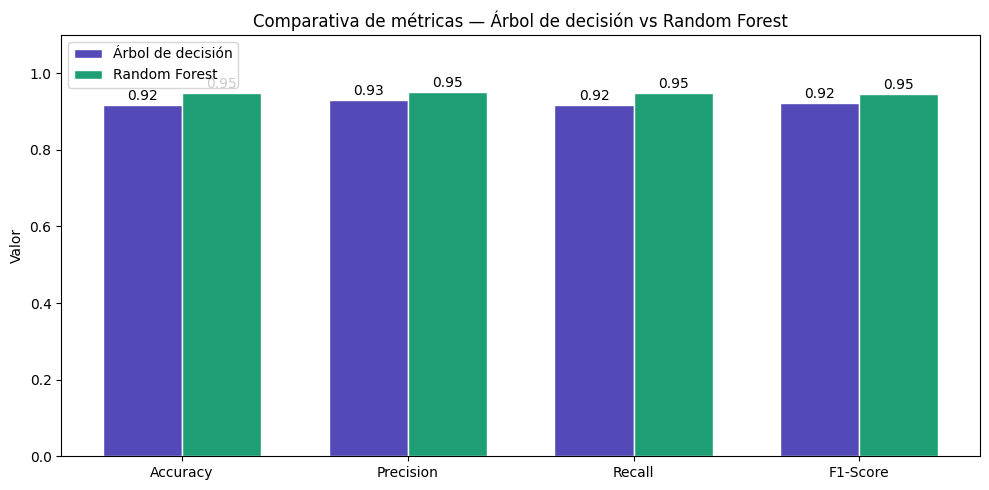

In [247]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calcular métricas automáticamente desde las predicciones
nombres = ['Árbol de decisión', 'Random Forest']
predicciones = [y_pred_arbol, y_pred_bosque]

accuracy  = [accuracy_score(y_test, y) for y in predicciones]
precision = [precision_score(y_test, y, average='weighted', zero_division=0) for y in predicciones]
recall    = [recall_score(y_test, y, average='weighted') for y in predicciones]
f1        = [f1_score(y_test, y, average='weighted', zero_division=0) for y in predicciones]

metricas = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1}

x = range(len(metricas))
ancho = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

barras1 = ax.bar([i - ancho/2 for i in x],
                  [v[0] for v in metricas.values()],
                  ancho, label='Árbol de decisión',
                  color='#534AB7', edgecolor='white')

barras2 = ax.bar([i + ancho/2 for i in x],
                  [v[1] for v in metricas.values()],
                  ancho, label='Random Forest',
                  color='#1D9E75', edgecolor='white')

for barra in list(barras1) + list(barras2):
    ax.text(barra.get_x() + barra.get_width()/2,
            barra.get_height() + 0.005,
            f'{barra.get_height():.2f}',
            ha='center', va='bottom', fontsize=10)

ax.set_xticks(list(x))
ax.set_xticklabels(metricas.keys())
ax.set_ylim(0, 1.1)
ax.set_ylabel('Valor')
ax.set_title('Comparativa de métricas — Árbol de decisión vs Random Forest')
ax.legend()
plt.tight_layout()
plt.show()

Construya un párrafo con los principales hallazgos.

## Discusión de los resultados obtenidos y argumentos sobre cómo se podrían mejorar de dichos resultados

Realice en este espacio todo el análsis de resultados final incluyendo: ventajas y desventajas de cada modelo propuesto, Resultados comparados. Conclusiones objetivas y significantes con base a las diferentes métricas escogidas. Recomendaciones de mejora de las propuestas: 